# RQ3: How are self-disclosure and offline social network related to well-being?
**Owner: Person D**

Rules: only the owner edits this notebook. Before saving to GitHub: *Runtime → Restart and run all*.

In [1]:
# ---- Shared setup cell: same in every notebook, don't change it alone ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

# Raw data (original study). Once data/clean.csv exists, switch to CLEAN_URL.
RAW_URL = "https://raw.githubusercontent.com/SALT-NLP/AI-companionship-well-being/main/data.csv"
CLEAN_URL = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv"

df = pd.read_csv(CLEAN_URL)
print(df.shape)

(1131, 17)


In [2]:
# Save a figure and download it (then upload it to figures/ on GitHub)
def save_fig(name):
    plt.savefig(name, dpi=200, bbox_inches="tight")
    try:
        from google.colab import files
        files.download(name)
    except ImportError:
        pass  # not in Colab: file is saved next to the notebook

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

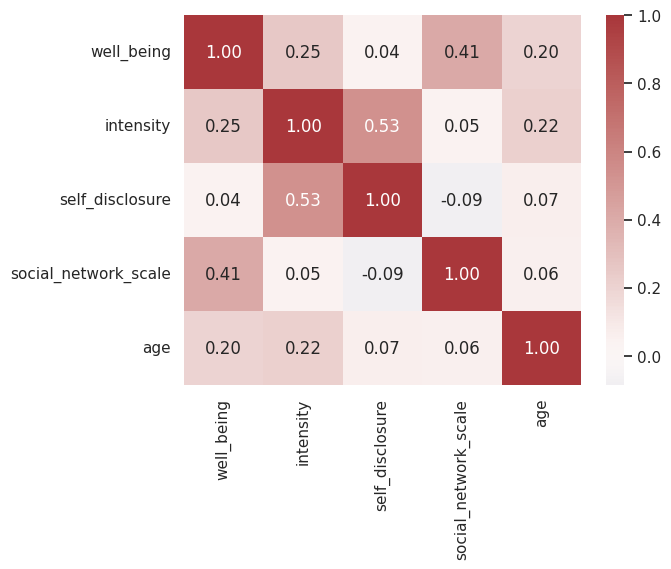

In [3]:
cols = ["well_being", "intensity", "self_disclosure", "social_network_scale", "age"]
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
save_fig("rq3_corr_heatmap.png")

In [4]:
model = smf.ols("well_being ~ self_disclosure + social_network_scale + intensity + age + single", data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             well_being   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     77.10
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.36e-69
Time:                        10:00:33   Log-Likelihood:                -1759.4
No. Observations:                1131   AIC:                             3531.
Df Residuals:                    1125   BIC:                             3561.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.5504      0.113     40.270      0.000       4.329       4.772
self_disclosure         -0.0736      0.041     -1.803      0.072      -0.154       0.007
social_network_scale     0.4958      0.035     14.260      0.000       0.428       0.564
intensity                0.2936      0.042      7.020      0.000       0.212       0.376
age                      0.0124      0.003      3.839      0.000       0.006       0.019
single                  -0.3498      0.072     -4.847      0.000      -0.491      -0.208
==============================================================================
Omnibus:                       20.897   Durbin-Watson:                   1.899
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.638
Skew:                          -0.259   Prob(JB):                     8.97e-05
Kurtosis:                       2.642   Cond. No.                         113.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""